# TLS Traffic Analysis by Miller, Huang, Joseph, and Tyga

### Traffic Analysis

In [traffic analysis](https://en.wikipedia.org/wiki/Traffic_analysis), (encrypted) messages are intercepted and examined to deduce information purely from communication patterns. Most importantly, traffic analysis can be performed on *encrypted* messages: even if the communicating parties, let's call them Alice and Bob, use a *provably secure* encryption scheme.

An encryption scheme that is provably secure even against attackers with unlimited computational capabilities is called *perfectly secret* or *information-theoretically secure*. In a nutshell, this is achieved by constructing an encryption system that produces ciphertexts which, in a mathematical sense, have too little information for the adversary Eve to succeed *regardless* of her cryptanalytic skills and computational power.

### CLINIC Attack

In the [CLINIC attack](https://arxiv.org/pdf/1403.0297), security researchers identified individual pages in the same website with 89% accuracy, exposing personal details including medical conditions, financial and legal affairs and sexual orientation.

CLINIC applies clustering techniques to identify patterns in TLS traffic. It uses Gaussian distribution to determine the similarity to each cluster of TLS traffic and maps traffic samples to a fixed-length feature vector which, in turn, is used for machine learning. Because of the similarity to the Bag-of-Words approach and the use of Gaussian distribution, CLINIC's authors refer to their technique as Bag-of-Gaussians (BoG).

After the initial classification, CLINIC applies a Hidden Markov Model (HMM) to leverage the link structure of the website in order to increase the attack's accuracy.

The figure below shows an overview of the attack. While the details of CLINIC are more involved, here's what happens in a nutshell. In the training phase, Eve generates a site graph which describes the website's link structure. She then uses clustering and Gaussian statistics to extract features from the encrypted TLS traffic which allow her to differentiate between individual web pages using logistic regression.

In the attack phase, Eve captures TLS traffic transmitted between Alice and Bob, and extracts the features. She then uses insights gained in the training phase to make an initial prediction. Finally, Eve applies a Hidden Markov Model with the site graph to further improve the accuracy of her final prediction.

![](img/CLINIC_overview.png)



### Feature Extraction

Let's have a detailed look at CLINIC attack's core - the feature extraction and the classification approach.

Initially, Eve extracts so-called traffic burst pairs from each *sample*, an instance of TLS traffic generated when a browser on Alice's or Bob's computer displays a webpage.

The burst pairs are defined as the *collective size of a contiguous outgoing packet sequence followed by the collective size of a contiguous incoming packet sequence*. In other words, outgoing sequences correspond to *requests*, and incoming sequences correspond to *responses*.

The figure below illustrates what burst pairs might look like for hypothetical samples "x", "+", and "o" (these are not real samples, just synthetic data to illustrate how CLINIC's feature extraction works). The clusters 1 to 8 are obtained using the k-means clustering.

![](img/CLINIC_example.png)

Once the clusters are formed, Eve fits a Gaussian distribution to each cluster and treats each cluster as a feature dimension, producing a fixed-width feature vector. Let's go through this process step by step.

In [78]:
import numpy as np

x = np.array([(0.5, 60), (1.6, 22),(4.2, 30), (1.1, 75), (2.0, 25)])
p = np.array([(1.1, 22), (4.0, 75), (4.2, 21)])
o = np.array([(1.8, 22), (2.4, 83), (4.2, 25), (1.4, 75), (4.0, 50)])

A Gaussian distribution, informally known as the bell curve, is defined by two parameters: the mean $\mu$ and the variance $\sigma^2$. Together, these parameters describe the shape of the distribution.

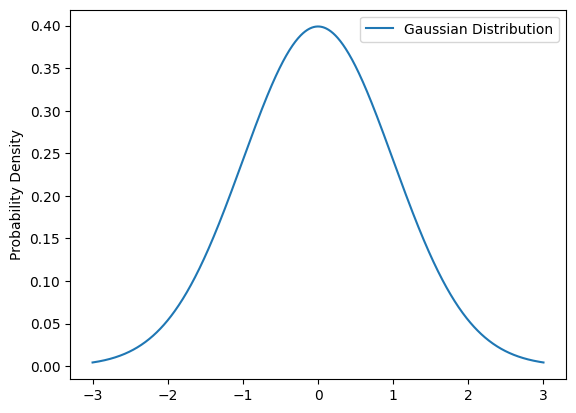

In [77]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the mean and standard deviation
mean = 0
std_dev = 1

# Generate a range of values for the x-axis
x = np.linspace(mean - 3*std_dev, mean + 3*std_dev, 1000)

# Compute the corresponding y-values using the Gaussian PDF
y = norm.pdf(x, mean, std_dev)

# Plot the values
plt.plot(x, y, label='Gaussian Distribution')

# Add title and labels
plt.ylabel('Probability Density')

# Add a legend
plt.legend()

# Show the plot
plt.show()

To fit a Gaussian distribution to a cluster, Eve has to estimate the mean and the variance such that the corresponding Gaussian distribution best describes the data points in that cluster.

The mean is simply the average of all points in the cluster. If data points are multi-dimensional, the mean is a vector where each element corresponds to the mean along one of the dimensions. As an example, the burst pairs `x[1]`, `p[0]` and `o[0]` belong to cluster 2.

Before computing the mean, though, Eve has to clean up the data by removing dimensions with constant values. This is needed because for every observed sample x, p, and o,  Eve eventually wants to compute the likelihood that this sample belongs to the identified clusters 1 to 8. Eve does this by computing the Gaussian Probability Density Function (PDF) for every burst pair in a specific cluster. Computing PDF, in turn, requires to invert the covariance matrix describing the Gaussian distribution of a cluster.

Dimensions with constant values like the incoming traffic of 22 KB in cluster 2 have a variance of 0. If such dimensions are included in the covariance matrix, the matrix cannot be inverted and, as a result, the PDF cannot be computed. Since a dimension whose values do not vary contributes no additional information, it can be dropped.

In [53]:
# Burst pairs belonging to cluster 1
cluster_1 = np.array([
    x[2],
    p[2],
    o[2]
])

# Identify and remove constant columns
non_constant_columns = np.any(cluster_1 != cluster_1[0, :], axis=0)
cluster_1 = cluster_1[:, non_constant_columns]

print("cluster 1 w/o constant columns:", cluster_1)

# Burst pairs belonging to cluster 2
cluster_2 = np.array([
    x[1],
    p[0],
    o[0]
])

# Identify and remove constant columns
non_constant_columns = np.any(cluster_2 != cluster_2[0, :], axis=0)
cluster_2 = cluster_2[:, non_constant_columns]

print("cluster 2 w/o constant columns:", cluster_2)

# Burst pairs belonging to cluster 6
cluster_6 = np.array([
    x[3],
    o[3]
])

# Identify and remove constant columns
non_constant_columns = np.any(cluster_6 != cluster_6[0, :], axis=0)
cluster_6 = cluster_6[:, non_constant_columns]

print("cluster 6 w/o constant columns:", cluster_6)



cluster 1 w/o constant columns: [[30.]
 [21.]
 [25.]]
cluster 2 w/o constant columns: [[1.6]
 [1.1]
 [1.8]]
cluster 6 w/o constant columns: [[1.1]
 [1.4]]


In [79]:
from scipy.stats import multivariate_normal

def fit_gaussian(data):
    """Fit a Gaussian distribution to the data"""
    # Step 1: Compute the mean vector
    mean = np.mean(data, axis=0)

    # Step 2: Compute the covariance matrix
    cov_matrix = np.cov(data, rowvar=False)

    # Step 3: Return a Gaussian distribution for given mean and covariance
    gaussian = multivariate_normal(mean=mean, cov=cov_matrix)

    return gaussian



In [116]:
# Step 4: Fit a Gaussian distribution to each cluster
gaussian_1 = fit_gaussian(cluster_1)
gaussian_2 = fit_gaussian(cluster_2)
gaussian_6 = fit_gaussian(cluster_6)

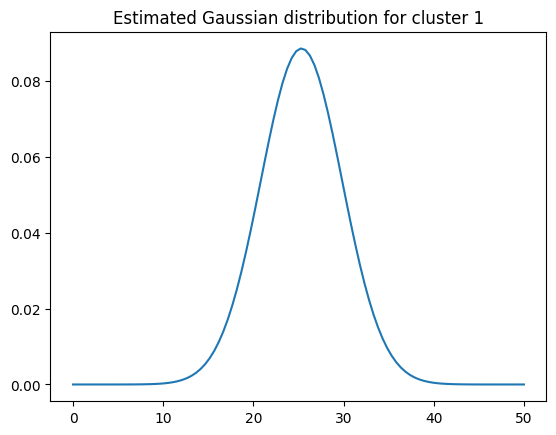

In [121]:
# Assuming gaussian_1 is already defined
# Example: gaussian_1 = multivariate_normal(mean=[0], cov=[[1]])

# Define the range of x-values
x = np.linspace(0, 50, 100)

# Compute the corresponding y-values using the PDF of gaussian_1
y = gaussian_1.pdf(x)

# Plot the values
plt.plot(x, y)

# Add title and labels
plt.title('Estimated Gaussian distribution for cluster 1')
#plt.xlabel('X-axis')
#plt.ylabel('Probability Density')

# Add a legend
#plt.legend()

# Show the plot
plt.show()

In [97]:
def compute_pdf(data, gaussian):
    """Compute the PDF of the given data for the given Gaussian distribution.
    
    Args:
        data (ndarray): The data points in a sample
        gaussian (multivariate_normal): Gaussian distribution
        
        Returns:
        ndarray: The PDF values for the given data points
    """
    return gaussian.pdf(data)

In [113]:
pdf = {}

# Step 5: Compute the PDF values (~likelihood) for each sample and each cluster

pdf['x_cluster_1'] = compute_pdf([[60], [22], [30]], gaussian_1)
pdf['p_cluster_1'] = compute_pdf([[22], [75], [21]], gaussian_1)
pdf['o_cluster_1'] = compute_pdf([[22], [83], [25]], gaussian_1)

pdf['x_cluster_2'] = compute_pdf([[0.5], [1.6], [4.2]], gaussian_2)
pdf['p_cluster_2'] = compute_pdf([[1.1], [4.0], [4.2]], gaussian_2)
pdf['o_cluster_2'] = compute_pdf([[1.8], [2.4], [4.2]], gaussian_2)

pdf['x_cluster_6'] = compute_pdf([[1.1], [2.0]], gaussian_6)
pdf['o_cluster_6'] = compute_pdf([[1.4], [4.0]], gaussian_6)

for key in pdf:
    print(f"PDF values for {key}")
    for k in pdf[key]:
        print(f"{k:.3f}")

    #print("Total PDF value for {}: {:.3f}".format(key, pdf[key]))



PDF values for x_cluster_1
0.000
0.067
0.052
PDF values for p_cluster_1
0.067
0.000
0.056
PDF values for o_cluster_1
0.067
0.000
0.088
PDF values for x_cluster_2
0.024
1.065
0.000
PDF values for p_cluster_2
0.598
0.000
0.000
PDF values for o_cluster_2
0.783
0.049
0.000
PDF values for x_cluster_6
1.465
0.004
PDF values for o_cluster_6
1.465
0.000


In [100]:
def total_pdf(pdf_values):
    """Compute the total PDF value for the given PDF values.
    
    Args:
        pdf_values (dict): Dictionary with PDF values for a specific sample and specific cluster
        
    Returns:
        float: The total PDF value
    """
    total_pdf = {}
    for key in pdf_values:
        total_pdf[key] = np.sum(pdf_values[key])

    return total_pdf

In [104]:
# Step 6: Compute the total likelihood (via PDF) for each sample x, p, o and each cluster 1, 2 and 6
total_pdf_values = total_pdf(pdf)
for key in total_pdf_values:
    print("Total PDF value for {}: {:.3f}".format(key, total_pdf_values[key]))

Total PDF value for x_cluster_1: 0.119
Total PDF value for p_cluster_1: 0.123
Total PDF value for o_cluster_1: 0.156
Total PDF value for x_cluster_2: 1.088
Total PDF value for p_cluster_2: 0.598
Total PDF value for o_cluster_2: 0.832
Total PDF value for x_cluster_6: 1.468
Total PDF value for o_cluster_6: 1.465


In [105]:
def normalize_pdf_values(pdf_values):
    """Normalize the PDF values.
    
    Args:
        pdf_values (arr): Array with PDF values for all (relevant) sample and a specific cluster
        
    Returns:
        array: Normalized PDF values
    """
    max_pdf = np.max(pdf_values)
    normalized_pdf_values = [pdf / max_pdf for pdf in pdf_values]

    return normalized_pdf_values

In [107]:
# Step 7: Normalize the total likelihood (via PDF) to the range [0,1]
normalized_pdf_cluster_1 = normalize_pdf_values([total_pdf_values['x_cluster_1'], total_pdf_values['p_cluster_1'], total_pdf_values['o_cluster_1']])
normalized_pdf_cluster_2 = normalize_pdf_values([total_pdf_values['x_cluster_2'], total_pdf_values['p_cluster_2'], total_pdf_values['o_cluster_2']])
normalized_pdf_cluster_6 = normalize_pdf_values([total_pdf_values['x_cluster_6'], total_pdf_values['o_cluster_6']])

print("Normalized PDF values for cluster 1:", normalized_pdf_cluster_1)
print("Normalized PDF values for cluster 2:", normalized_pdf_cluster_2)
print("Normalized PDF values for cluster 6:", normalized_pdf_cluster_6)

Normalized PDF values for cluster 1: [np.float64(0.7657219807338089), np.float64(0.7912114311102201), np.float64(1.0)]
Normalized PDF values for cluster 2: [np.float64(1.0), np.float64(0.549426865119053), np.float64(0.7642759396813252)]
Normalized PDF values for cluster 6: [np.float64(1.0), np.float64(0.9975273768433652)]


## References

* Brad Miller, Ling Huang, A. D. Joseph, and J. D. Tygar "I Know Why You Went to the Clinic: Risks and Realization of HTTPS Traﬃc Analysis", 2014, [arxiv.org](https://arxiv.org/pdf/1403.0297)